In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exercise   05.1

## Metropolis Implementation
Defining the pointer to function 
```C++
typedef double(*prob)(const vector<double>&);
```
I implemented the metropolis algorithm as 

```C++
vector<double> metropolis(
	const vector <double> x0, 
	prob p, 
	Random& rnd, double sigma,      // parameter of the guess distribution
	vector<float> &acceptance_rate, // vector to store the acceptance 
	string flag="gauss"             // flag for the guess distribution
)
{
	vector<double> x (3); 

	// generate new point using flag distribution
	if ((flag=="gauss") || (flag=="Gauss") || (flag=="GAUSS"))
	{
		x[0] = rnd.Gauss(x0[0], sigma);
		x[1] = rnd.Gauss(x0[1], sigma);
		x[2] = rnd.Gauss(x0[2], sigma);
	}
	else if((flag=="uniform") || (flag=="Uniform") || (flag=="UNIFORM")) 
	{
		x[0] = rnd.Rannyu(x0[0]- sigma, x0[0]+sigma);
		x[1] = rnd.Rannyu(x0[1]- sigma, x0[1]+sigma);
		x[2] = rnd.Rannyu(x0[2]- sigma, x0[2]+sigma);

	}else
	{
		cerr<<"No such distribution--using uniform distribution as default"
                    <<endl;
		x[0] = rnd.Rannyu(x0[0]- sigma, x0[0]+sigma);
		x[1] = rnd.Rannyu(x0[1]- sigma, x0[1]+sigma);
		x[2] = rnd.Rannyu(x0[2]- sigma, x0[2]+sigma);		
	}

	double alpha =p(x)/p(x0); //both distribution are simmetric
	//accept/ reject

	double r = rnd.Rannyu();


	if (r<=alpha)
	{
		acceptance_rate.push_back(acceptance_rate.back()+1);	
		return x;
	}else
	{
		acceptance_rate.push_back(acceptance_rate.back());	
 		return x0;
	}


}

```

Both the initial guess distributions (Uniform and Gaussian) are simmetric so in the metropolis algorithm the accept/reject process is independent of the analitic form of the initial distribution.


## Uniform distribution

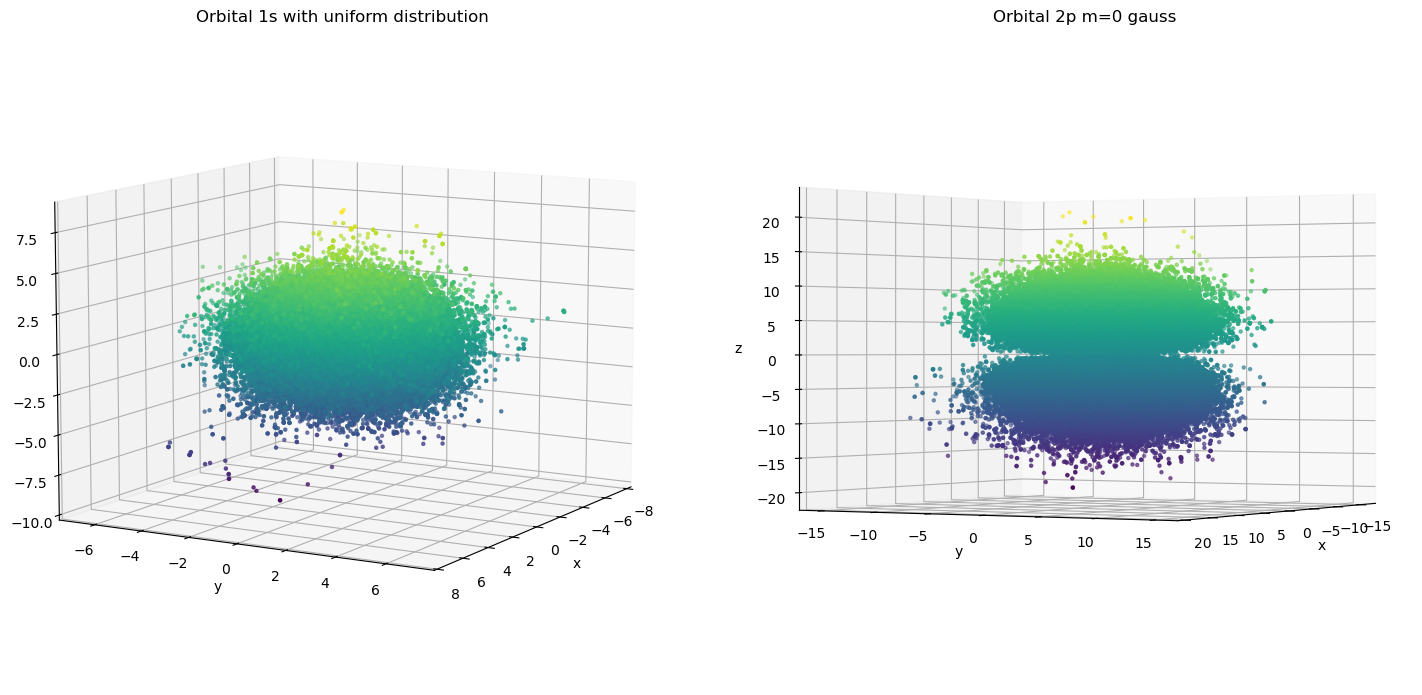

In [78]:
u1s=pd.read_csv('data/pos_1s_unif.csv')

fig= plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(u1s.x, u1s.y, u1s.z, c=u1s.z, marker='.')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.view_init(10, 30)
ax1.set_title('Orbital 1s with uniform distribution')


u2p=pd.read_csv('data/pos_2p_unif.csv')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(u2p.x, u2p.y, u2p.z, c=u2p.z, marker='.')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.view_init(0, 30)
ax2.set_title('Orbital 2p m=0 gauss')


plt.tight_layout()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6147/602038143.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax[0, 1].set_ylabel('$\sigma_r$')
/tmp/ipykernel_6147/602038143.py:33: SyntaxWarning: invalid escape sequence '\s'
  ax[1, 1].set_ylabel('$\sigma_r$')


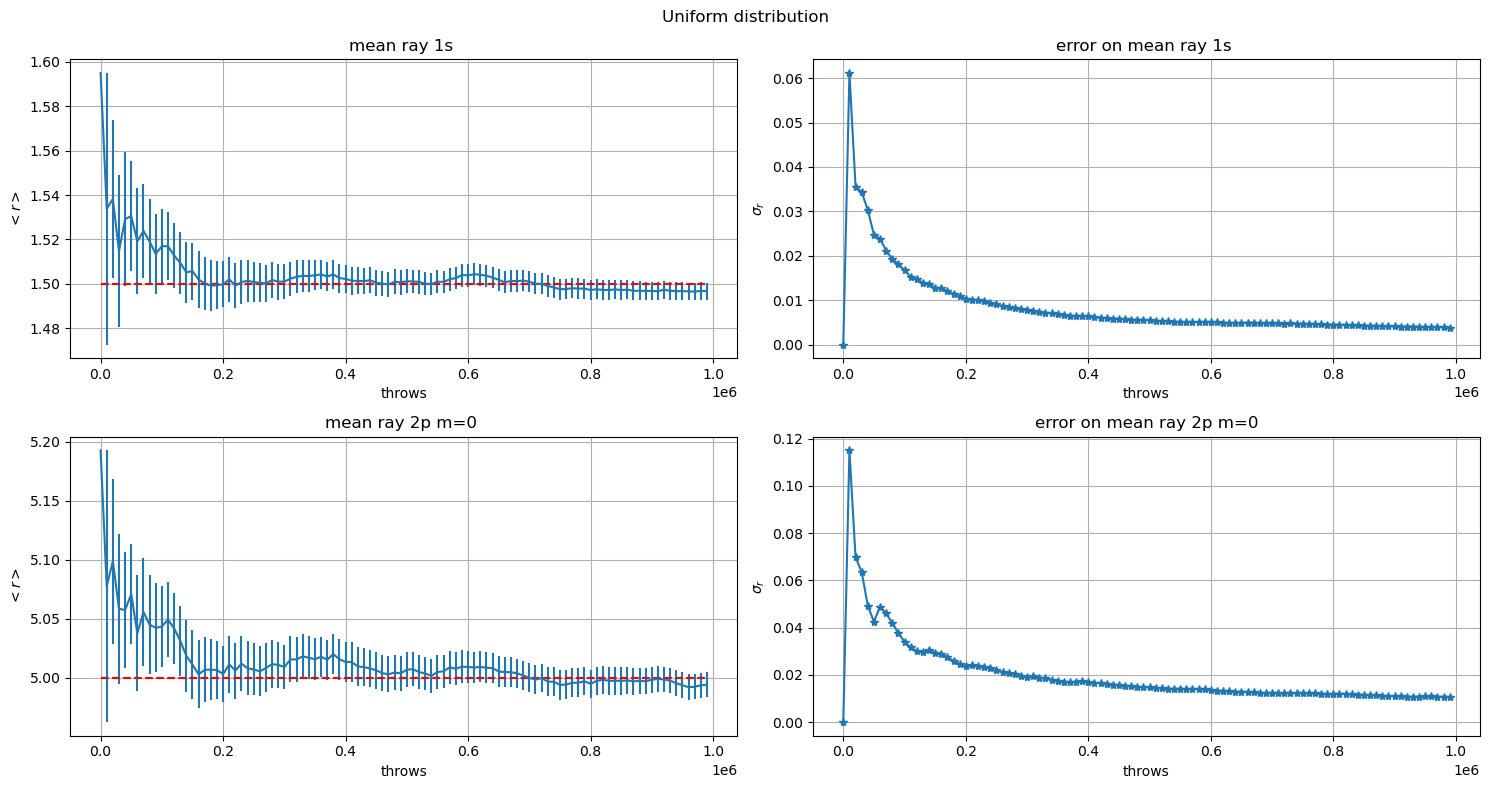

In [97]:
ru1s=pd.read_csv('data/ray_1s_unif.csv')

fig, ax = plt.subplots(2, 2, figsize=(15,8))
fig.suptitle('Uniform distribution')
ax[0, 0].errorbar(ru1s.throws, ru1s.avg, yerr=ru1s.err)
ax[0, 0].hlines(1.5, 0, ru1s.throws[len(ru1s)-1], color='r', ls='--')
ax[0, 0].set_title('mean ray 1s ')
ax[0, 0].set_ylabel('$< r >$')
ax[0, 0].set_xlabel('throws')

ax[0, 0].grid(True)

ax[0, 1].set_title('error on mean ray 1s ')
ax[0, 1].plot(ru1s.throws, ru1s.err, '-*')
ax[0, 1].grid(True)
ax[0, 1].set_ylabel('$\sigma_r$')
ax[0, 1].set_xlabel('throws')


ru2p=pd.read_csv('data/ray_2p_unif.csv')


ax[1, 0].set_title('mean ray 2p m=0 ')
ax[1, 0].errorbar(ru2p.throws, ru2p.avg, yerr=ru2p.err)
ax[1, 0].hlines(5, 0, ru2p.throws[len(ru2p)-1], color='r', ls='--')
ax[1, 0].grid(True)
ax[1, 0].set_ylabel('$< r >$')
ax[1, 0].set_xlabel('throws')

ax[1, 1].set_title('error on mean ray 2p m=0')
ax[1, 1].plot(ru2p.throws, ru2p.err, '-*')
ax[1, 1].grid(True)
ax[1, 1].set_ylabel('$\sigma_r$')
ax[1, 1].set_xlabel('throws')

plt.tight_layout()
plt.show()

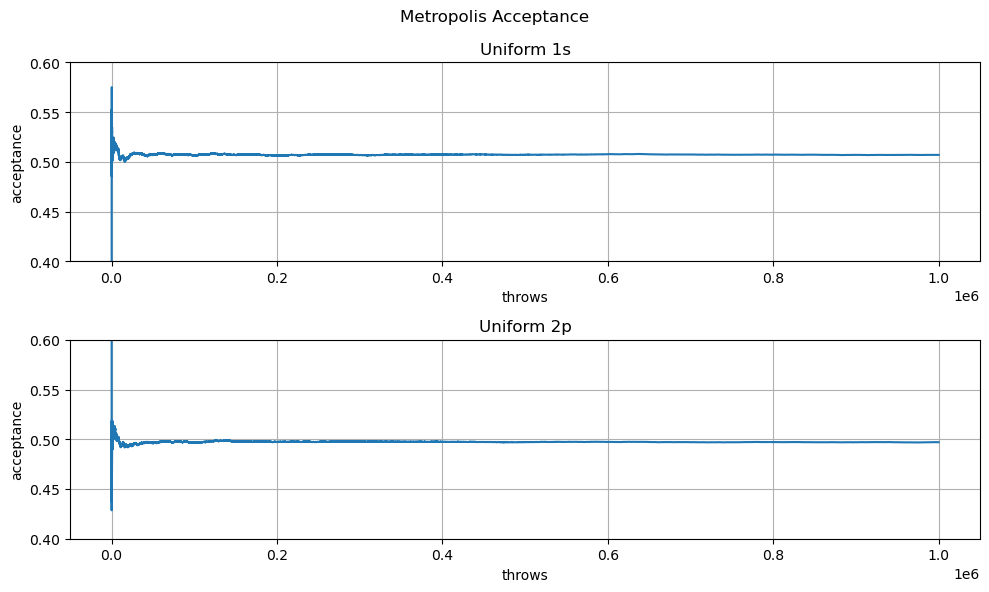

In [95]:
a1s = pd.read_csv('data/acceptance_pos_1s_unif.csv')
a1s['rate']=a1s['avg']/a1s['throws']
a2p = pd.read_csv('data/acceptance_pos_2p_unif.csv')
a2p['rate']=a2p['avg']/a2p['throws']


fig, ax = plt.subplots(2,1,figsize=(10, 6))
fig.suptitle('Metropolis Acceptance')
ax[0].plot(a1s.rate)
ax[0].grid()
ax[0].set_ylim([0.4, 0.6])
ax[0].set_title('Uniform 1s')
ax[0].set_ylabel('acceptance')
ax[0].set_xlabel('throws')


ax[1].plot(a2p.rate)
ax[1].grid()
ax[1].set_title('Uniform 2p')
ax[1].set_ylim([0.4, 0.6])
ax[1].set_ylabel('acceptance')
ax[1].set_xlabel('throws')

plt.tight_layout()
plt.show()

# a1s


## Gaussian distribution

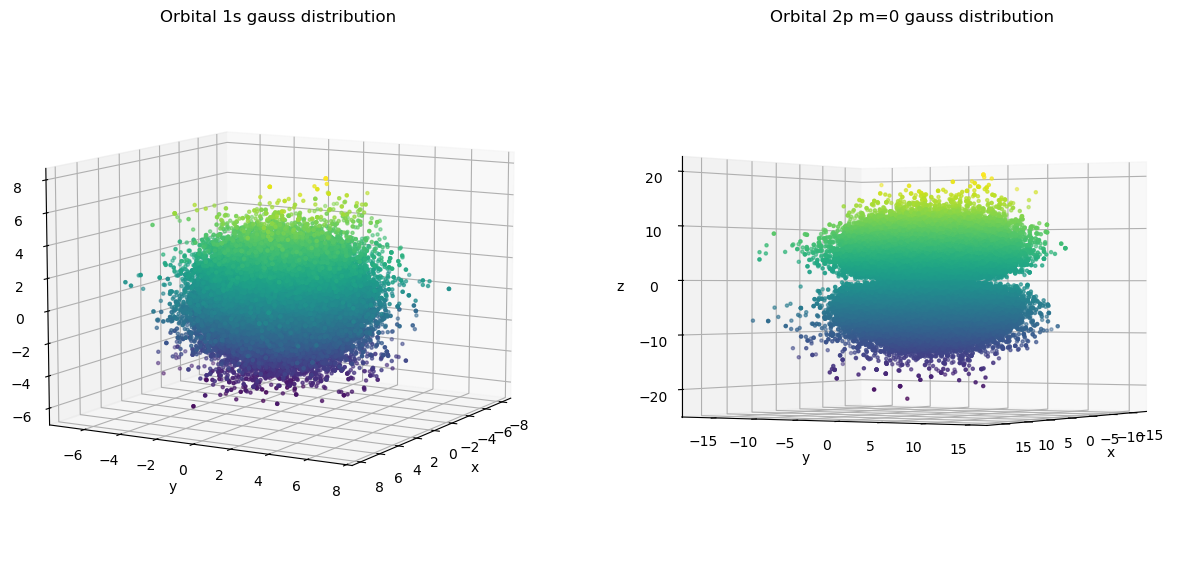

In [81]:
g1s=pd.read_csv('data/pos_1s_gauss.csv')

fig= plt.figure(figsize=(15, 7))
ax = fig.add_subplot(1, 2,1, projection='3d')
ax.scatter(g1s.x, g1s.y, g1s.z, c=g1s.z, marker='.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 30)
ax.set_title('Orbital 1s gauss distribution')


g2p=pd.read_csv('data/pos_2p_gauss.csv')
ax = fig.add_subplot(1,2,2,projection='3d')
ax.scatter(g2p.x, g2p.y, g2p.z, c=g2p.z, marker='.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(0, 30)
ax.set_title('Orbital 2p m=0 gauss distribution')


plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6147/3999903622.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax[0,1].set_ylabel('$\sigma_r$')
/tmp/ipykernel_6147/3999903622.py:32: SyntaxWarning: invalid escape sequence '\s'
  ax[1,1].set_ylabel('$\sigma_r$')


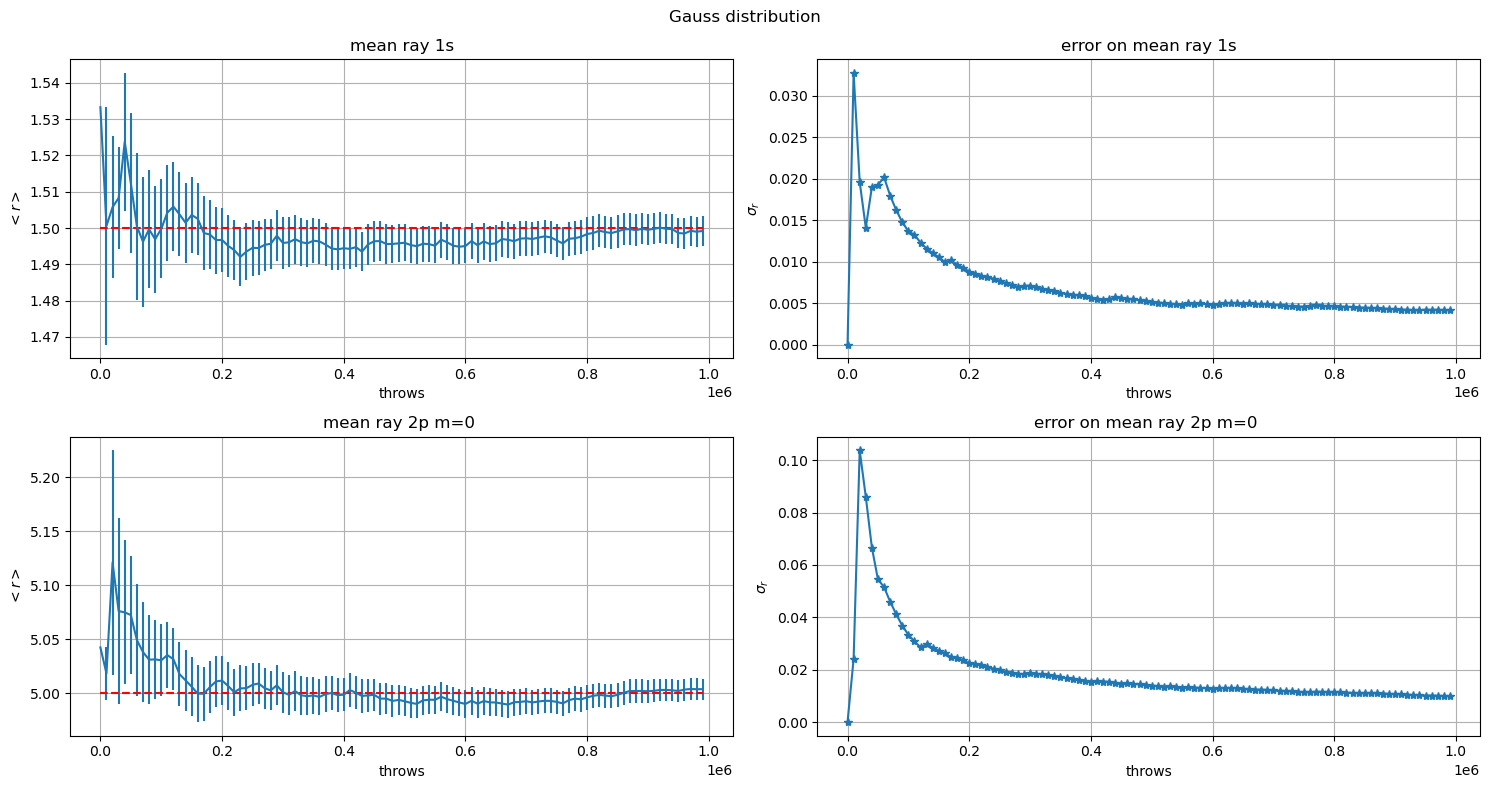

In [94]:
r1s=pd.read_csv('data/ray_1s_gauss.csv')

fig, ax = plt.subplots(2, 2, figsize=(15,8))
fig.suptitle('Gauss distribution')

ax[0,0].set_title('mean ray 1s')
ax[0,0].errorbar(r1s.throws, r1s.avg, yerr=r1s.err)
ax[0,0].hlines(1.5, 0, ru1s.throws[len(ru1s)-1], color='r', ls='--')
ax[0,0].grid(True)
ax[0,0].set_ylabel('$< r >$')
ax[0,0].set_xlabel('throws')

ax[0,1].set_title('error on mean ray 1s')
ax[0,1].plot(r1s.throws, r1s.err, '-*')
ax[0,1].grid(True)
ax[0,1].set_ylabel('$\sigma_r$')
ax[0,1].set_xlabel('throws')

r2p=pd.read_csv('data/ray_2p_gauss.csv')


ax[1,0].set_title('mean ray 2p m=0 ')
ax[1,0].errorbar(r2p.throws, r2p.avg, yerr=r2p.err)
ax[1,0].hlines(5, 0, r2p.throws[len(r2p)-1], color='r', ls='--')
ax[1,0].grid(True)
ax[1,0].set_ylabel('$< r >$')
ax[1,0].set_xlabel('throws')

ax[1,1].set_title('error on mean ray 2p m=0 ')
ax[1,1].plot(r2p.throws, r2p.err, '-*')
ax[1,1].grid(True)
ax[1,1].set_ylabel('$\sigma_r$')
ax[1,1].set_xlabel('throws')

plt.tight_layout()
plt.show()

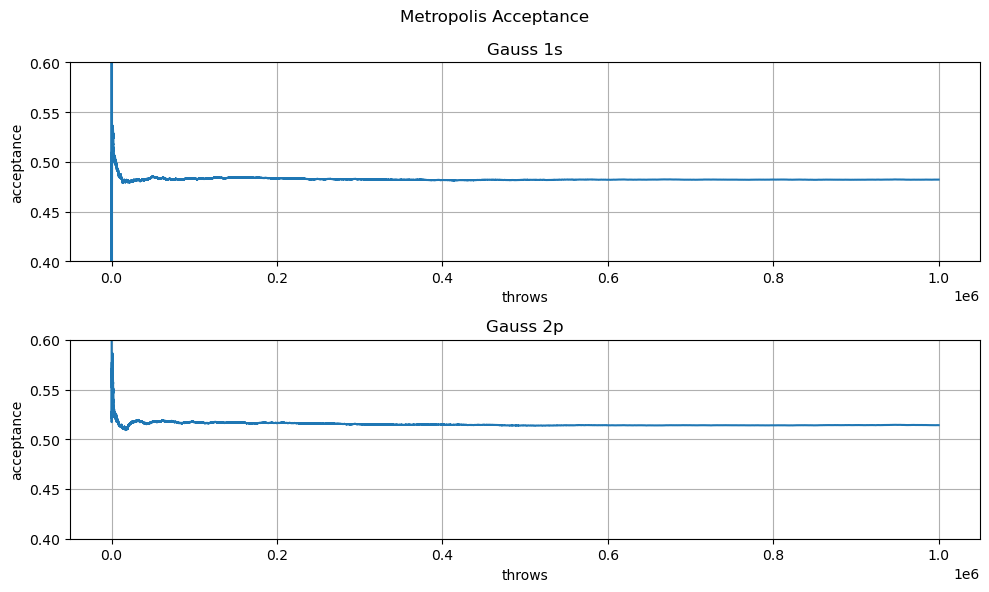

In [96]:
a1s = pd.read_csv('data/acceptance_pos_1s_gauss.csv')
a1s['rate']=a1s['avg']/a1s['throws']



a2p = pd.read_csv('data/acceptance_pos_2p_gauss.csv')
a2p['rate']=a2p['avg']/a2p['throws']

fig, ax = plt.subplots(2,1,figsize=(10, 6))
fig.suptitle('Metropolis Acceptance')
ax[0].plot(a1s.rate)
ax[0].grid()
ax[0].set_ylim([0.4, 0.6])
ax[0].set_title('Gauss 1s')
ax[0].set_ylabel('acceptance')
ax[0].set_xlabel('throws')

ax[1].plot(a2p.rate)
ax[1].grid()
ax[1].set_title('Gauss 2p')
ax[1].set_ylim([0.4, 0.6])
ax[1].set_ylabel('acceptance')
ax[1].set_xlabel('throws')

plt.tight_layout()
plt.show()

# a1s

The results using as initial guess distribution the uniform  distribution or gaussian distribution seems to be completely equivalent.



## Visualization 1S e 2P

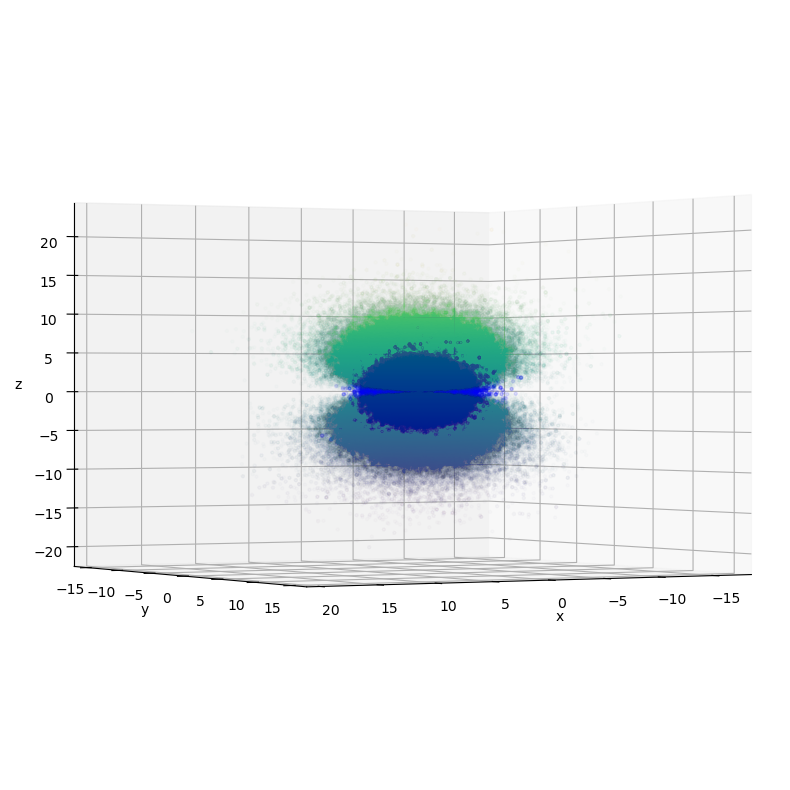

In [85]:

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')
ax.scatter(u2p.x, u2p.y, u2p.z, c=u2p.z, alpha=0.01, marker='.')
ax.scatter(u1s.x, u1s.y, u1s.z, c='b', alpha=0.1, marker='.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(0, 60)

plt.show()

# Other orbitals

In [17]:
df2s=pd.read_csv('data/pos_2s_gauss.csv')
df3s=pd.read_csv('data/pos_3s_gauss.csv')
df3p=pd.read_csv('data/pos_3p_m0_gauss.csv')
df3dm0=pd.read_csv('data/pos_3d_m0_gauss.csv')


/tmp/ipykernel_564274/943111298.py:2: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


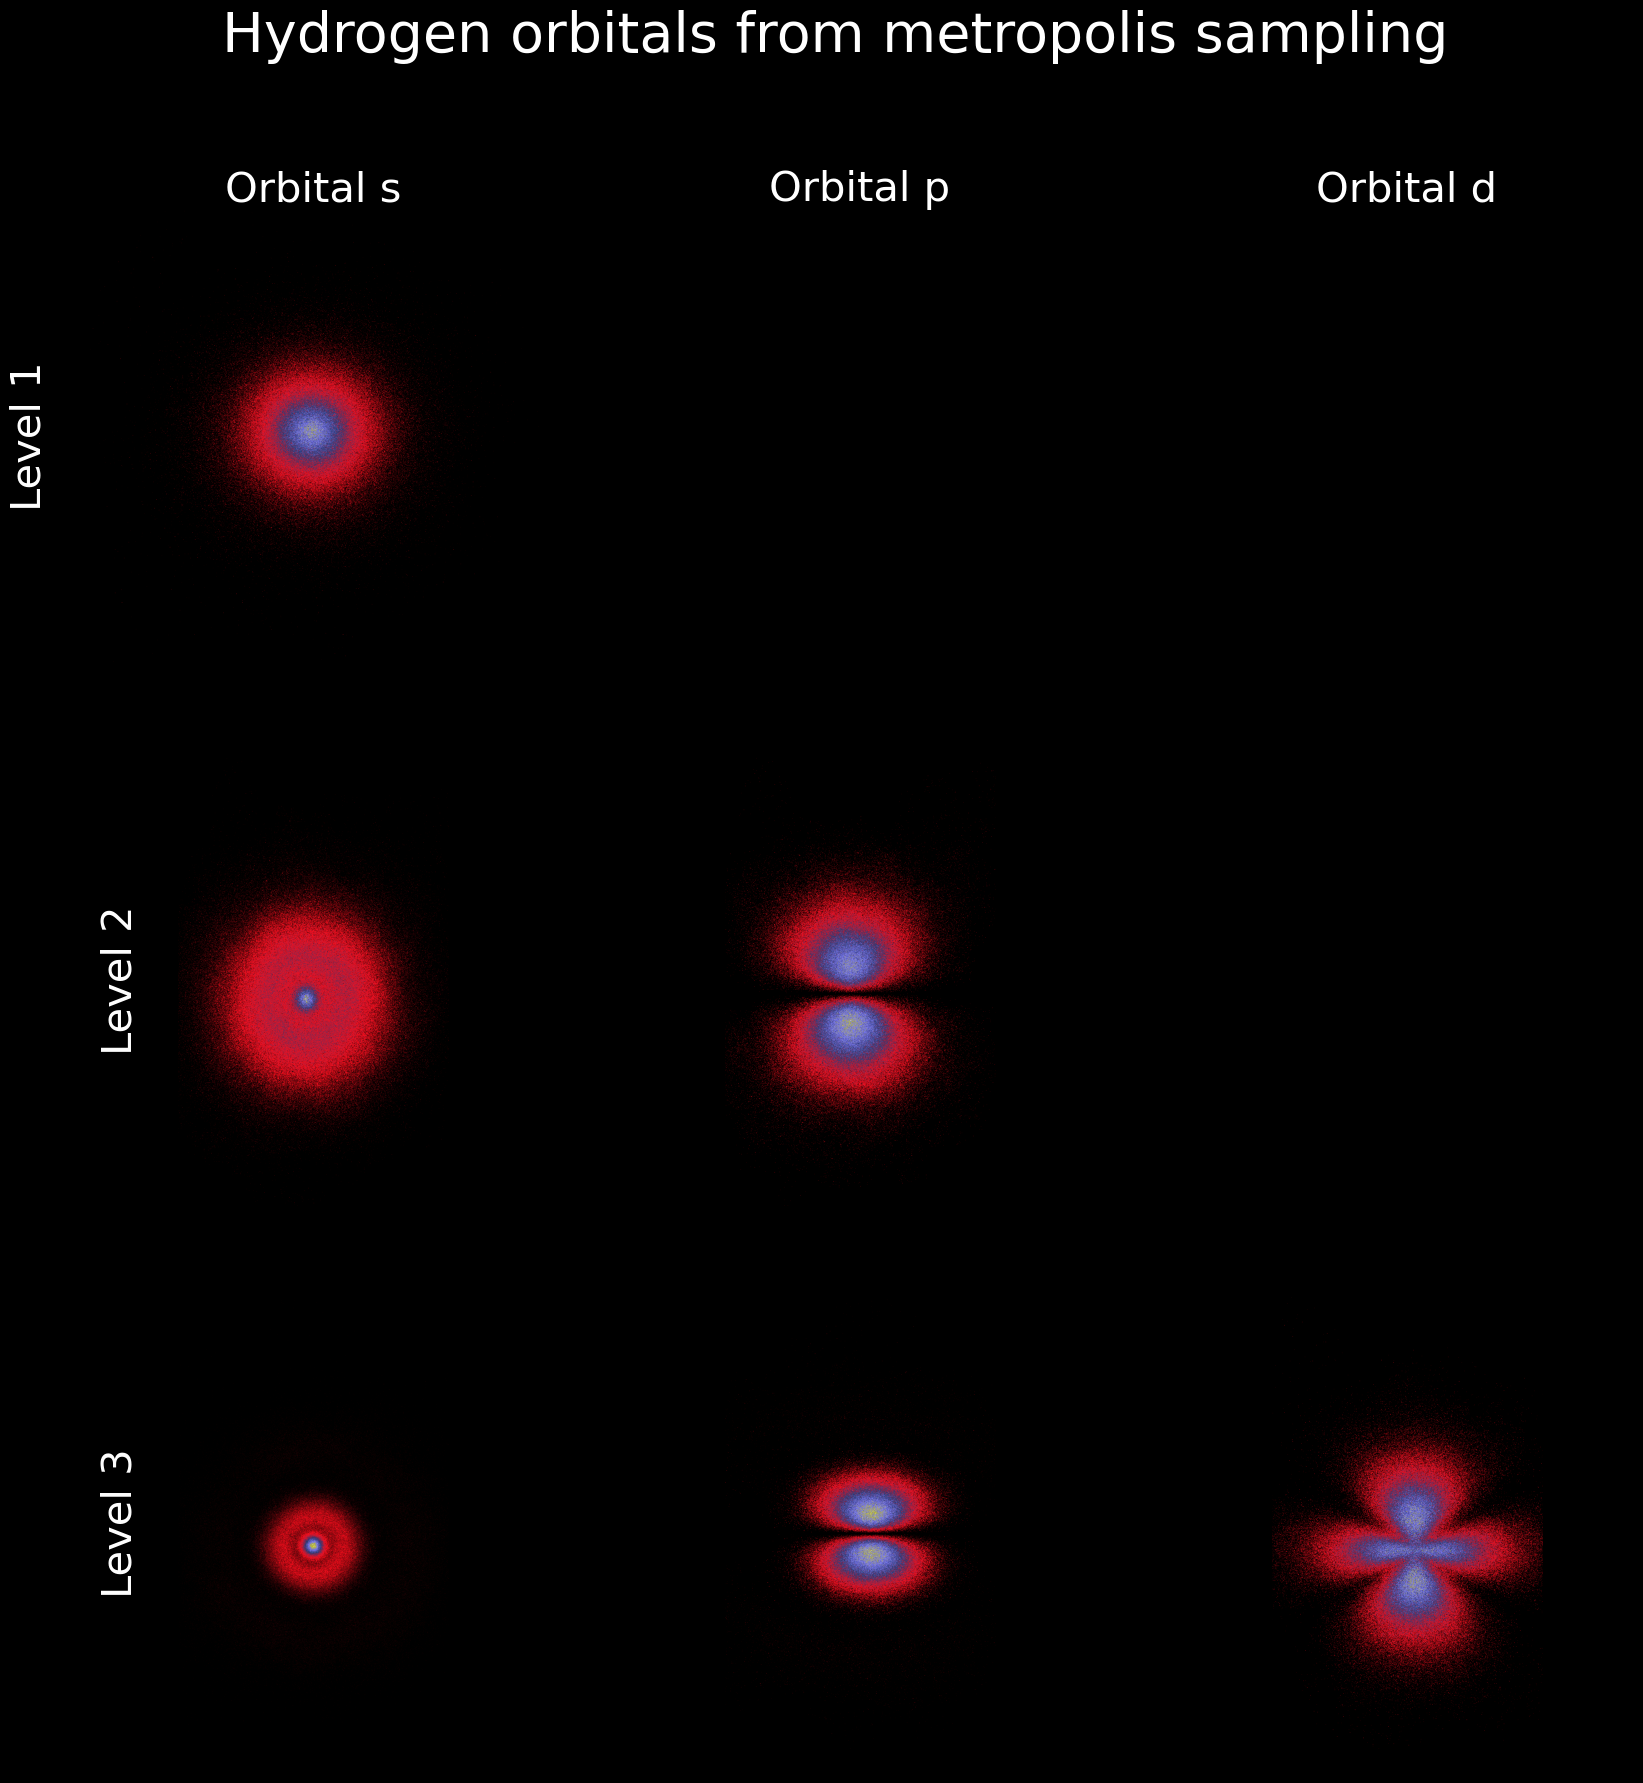

In [73]:
import matplotlib.cm as cm
from scipy.ndimage.filters import gaussian_filter
fig, ax = plt.subplots(3, 3)
fig.set_figwidth(20)
fig.set_figheight(20)


c=cm.gist_stern

bins=1000
heatmap, xedges, yedges = np.histogram2d(
    df1s.x, df1s.z, bins=bins
)
ax[0,0].imshow(heatmap.T,# extent=extent, 
               aspect='equal',
               #origin='lower',
               cmap=c)
ax[0,0].set_title('Orbital s', c='w', size=30)
ax[0,1].set_title('Orbital p', c='w', size=30)
ax[0,2].set_title('Orbital d', c='w', size=30)

ax[0,1].imshow(np.zeros((bins,bins)), cmap=c)
ax[0,2].imshow(np.zeros((bins,bins)), cmap=c)


ax[0,0].set_ylabel('Level 1', c='w', labelpad=0, size=30)
ax[1,0].set_ylabel('Level 2', c='w', labelpad=0, size=30)
ax[2,0].set_ylabel('Level 3', c='w', labelpad=0, size=30)

heatmap, xedges, yedges = np.histogram2d(
    df2s.x, df2s.z, bins=bins
)
ax[1,0].imshow(heatmap.T, #extent=extent,
               aspect='equal', 
               #origin='lower',
               cmap=c)

heatmap, xedges, yedges = np.histogram2d(
    df2p.x, df2p.z, bins=bins
)
ax[1,1].imshow(heatmap.T,
               #extent=extent, 
               aspect='equal',
               #origin='lower', 
               cmap=c)
ax[1,2].imshow(np.zeros((bins,bins)), cmap=c)

for k in range(3):
    ax[1,k].set_xlim([200, 800])

heatmap, xedges, yedges = np.histogram2d(
    df3s.x, df3s.z, bins=bins
)
ax[2,0].imshow(heatmap.T,
               #extent=extent, 
               aspect='equal',#origin='lower', 
               cmap=c)


heatmap, xedges, yedges = np.histogram2d(df3dm0.x, df3dm0.z, bins=bins)
ax[2,2].imshow(heatmap.T,# extent=extent, 
               aspect='equal',# origin='lower', 
               cmap=c)

heatmap, xedges, yedges = np.histogram2d(df3p.x, df3p.z, bins=bins)
ax[2,1].imshow(heatmap.T,
               #extent=extent,
               aspect='equal', #origin='lower' , 
               cmap=c)
for k in range(3):
    ax[2,k].set_xlim([200, 800])

fig.set_facecolor('black')
fig.suptitle('Hydrogen orbitals from metropolis sampling', c='w', size=40)
plt.show()